In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_11_13_1:                      Date       Bitrate   Packet rate
0    2016-05-11 10:58:54  3.630401e+08  58983.439566
1    2016-05-11 10:58:55  3.712497e+08  61279.843334
2    2016-05-11 10:58:56  3.771228e+08  61655.583017
3    2016-05-11 10:58:57  3.088193e+08  52809.991598
4    2016-05-11 10:58:58  3.125021e+08  54009.252938
...                  ...           ...           ...
7195 2016-05-11 12:58:49  2.783933e+08  47863.618726
7196 2016-05-11 12:58:50  2.838655e+08  48931.319337
7197 2016-05-11 12:58:51  2.761552e+08  47729.439200
7198 2016-05-11 12:58:52  2.786259e+08  48758.061702
7199 2016-05-11 12:58:53  2.947294e+08  51598.561384

[7200 rows x 3 columns]
df_11_13:                      Date       Bitrate   Packet rate
0    2016-05-13 10:58:54  3.199680e+08  52735.756090
1    2016-05-13 10:58:55  3.129495e+08  51196.075054
2    2016-05-13 10:58:56  3.218190e+08  53366.841739
3    2016-05-13 10:58:57  3.318047e+08  53705.038805
4    2016-05-13 10:58:58  3.340817e+08  53908.6917

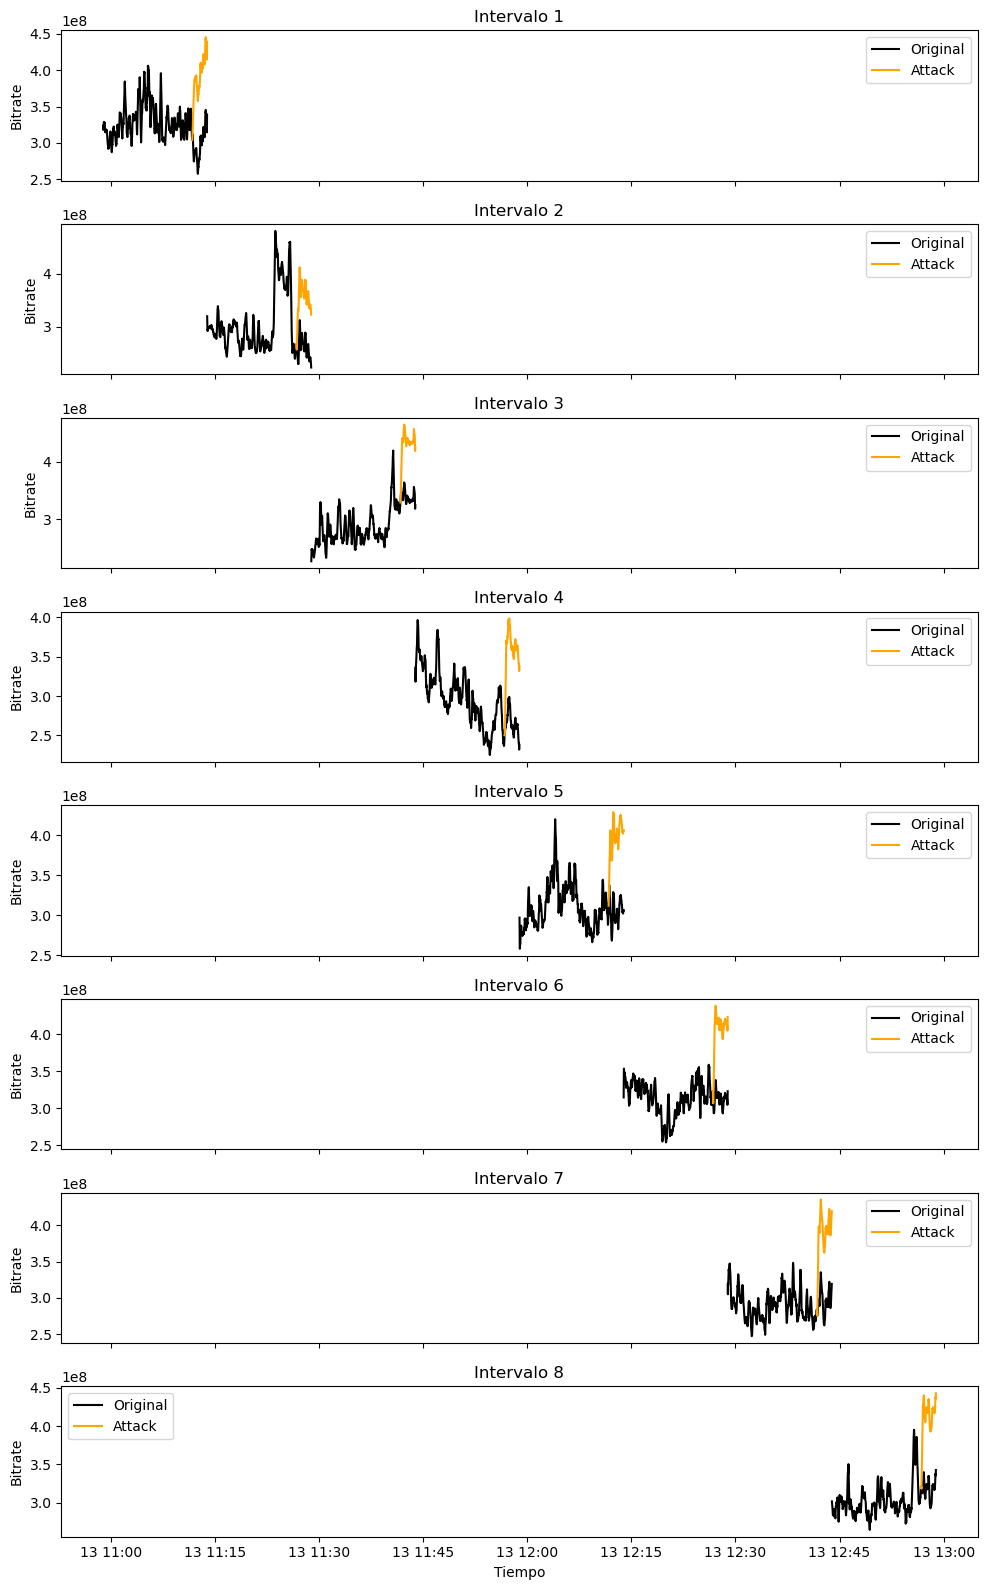

In [2]:
from utilities import *

ataque_rampa_1 = ugr_load_data("may", 3) 
#print('ar1:',ataque_rampa_1)
ataque_rampa_2 = ugr_concat_data_list([ataque_rampa_1])
ataque_rampa_2 = ugr_get_first_n_days(ataque_rampa_2, 5)
#print('ar2: ', ataque_rampa_2)
ataque_rampa_3 = ugr_get_few_minutes(ataque_rampa_2, 11*60-1-9/60, 15) 
#print('ar3: ', ataque_rampa_3)
#df_11_13 = ugr_get_few_minutes(ataque_rampa_2, 11*60, 120) #Lunes
#df_11_13_1 = ugr_get_few_minutes(ataque_rampa_2, 35*60, 120) #Martes
df_11_13_1 = ugr_get_few_minutes(ataque_rampa_2, 59*60, 120) #Miercoles
#df_11_13 = ugr_get_few_minutes(ataque_rampa_2, 83*60, 120) #Jueves
df_11_13 = ugr_get_few_minutes(ataque_rampa_2, 107*60, 120) #Viernes
print('df_11_13_1: ', df_11_13_1)
print('df_11_13: ', df_11_13)
ataque_rampa_33 = ataque_rampa_3.copy()


def apply_attack(df, attackMin, method):
    total_samples = attackMin * 60  # asumiendo 1 muestra por segundo
    if method == 0:
        df.loc[df.index[-total_samples:], "Bitrate"] = df.loc[df.index[-total_samples:], "Bitrate"] + (10**8) #original
        #df.loc[df.index[-total_samples:], "Bitrate"] = df.loc[df.index[-total_samples:], "Bitrate"] + (10**8)*3.3 #cambio intensidades
    elif method == 1:
        #ramp = [1 + (i/total_samples)*0.5 for i in range(total_samples)] #original
        ramp = [1 + (i/total_samples)*2 for i in range(total_samples)] #cambio_intensidades
        ramp = np.array(ramp)
        df.loc[df.index[-total_samples:], "Bitrate"] = df.loc[df.index[-total_samples:], "Bitrate"] * ramp
    return df




chunks = []
n_chunks = 8  # De 11:00 a 13:00 hay 2 horas = 8 intervalos de 15 min
for i in range(n_chunks):
    start_idx = i * 900
    end_idx = (i + 1) * 900
    chunk_i = df_11_13.iloc[start_idx:end_idx].copy()
    chunks.append(chunk_i)


ossef = 770  # offset para empezar a graficar la versión atacada
fig, axes = plt.subplots(nrows=len(chunks), figsize=(10, 16), sharex=True)

for i, chunk_df in enumerate(chunks):
    df_copy = chunk_df.copy()
    
    bitrate_smooth = smooth(df_copy["Bitrate"], 10)
    #bitrate_smooth = df_copy["Bitrate"]
    
    
    #df_attack = apply_attack(df_copy, 2, 1)  # ATAQUE RAMPA 
    df_attack = apply_attack(df_copy, 2, 0)  # ATAQUE MESETA 
    bitrate_attack_smooth = smooth(df_attack["Bitrate"], 10)
    #bitrate_attack_smooth = df_attack["Bitrate"]
    
    axes[i].plot(df_copy["Date"], bitrate_smooth, color="black", label="Original")
    axes[i].plot(df_copy["Date"][ossef:], bitrate_attack_smooth[ossef:], color="orange", label="Attack")
    
    axes[i].set_title(f"Intervalo {i+1}")
    axes[i].set_ylabel("Bitrate")
    axes[i].legend()

    #GUARDAR
    #filename = f"ataque_rampa/cambio_intensidades/bitrate_interval_mie{i}_intens1+_1_5_2intento.csv"
    #filename = f"ataque_meseta/cambio_intensidades/bitrate_interval_mie{i}_intens1+_3_3_2intento.csv"
    #pd.DataFrame(bitrate_attack_smooth).to_csv(filename, header=False, index=False)
    #print(f"Archivo guardado: {filename}")

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()


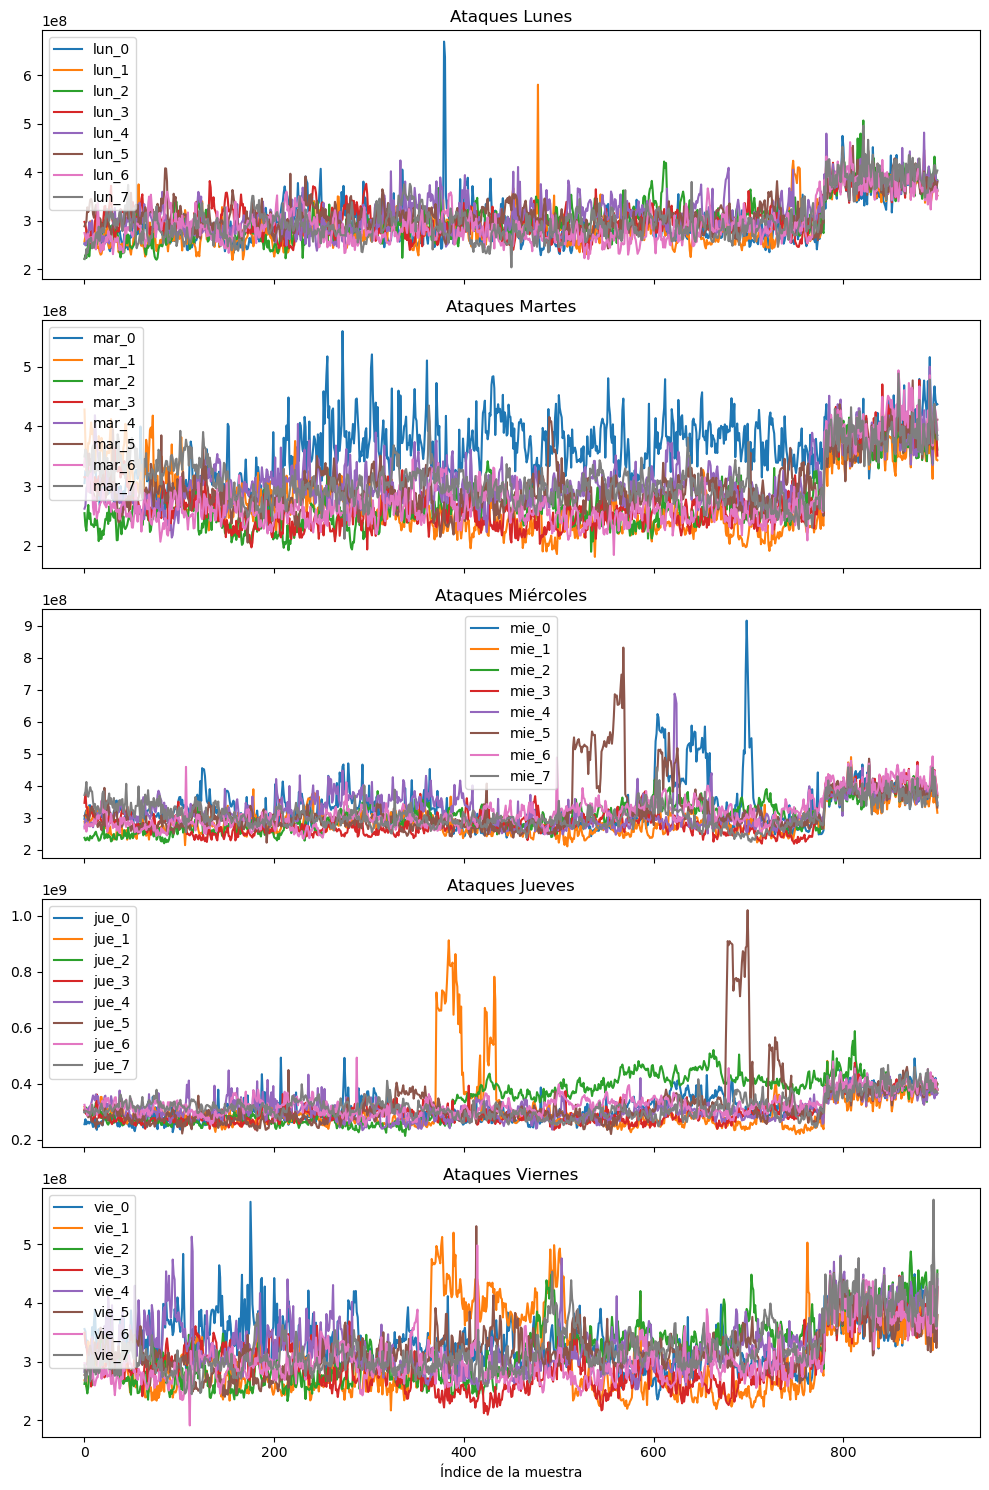

In [3]:
import matplotlib.pyplot as plt

ataque_rampa_1 = ugr_load_data("may", 3)
ataque_rampa_2 = ugr_concat_data_list([ataque_rampa_1])
ataque_rampa_2 = ugr_get_first_n_days(ataque_rampa_2, 1)
ataque_rampa_3 = ugr_get_few_minutes(ataque_rampa_2, 11*60-1-9/60, 15)


data_orig_lun = {}
data_atk_lun = {}
data_orig_mar = {}
data_atk_mar = {}
data_orig_mie = {}
data_atk_mie = {}
data_orig_jue = {}
data_atk_jue = {}
data_orig_vie = {}
data_atk_vie = {}

for i in range(8):  
    data_orig_lun[i] = pd.read_csv(f'series_originales/bitrate_original_lun_{i}.csv', header=None, names=['traffic'])
    data_atk_lun[i] = pd.read_csv(f'series_ataque65/bitrate_attack_lun{i}.csv', header=None, names=['traffic'])
    data_orig_mar[i] = pd.read_csv(f'series_originales/bitrate_original_mar_{i}.csv', header=None, names=['traffic'])
    data_atk_mar[i] = pd.read_csv(f'series_ataque65/bitrate_attack_mar{i}.csv', header=None, names=['traffic'])
    data_orig_mie[i] = pd.read_csv(f'series_originales/bitrate_original_mie_{i}.csv', header=None, names=['traffic'])
    data_atk_mie[i] = pd.read_csv(f'series_ataque65/bitrate_attack_mie{i}.csv', header=None, names=['traffic'])
    data_orig_jue[i] = pd.read_csv(f'series_originales/bitrate_original_jue_{i}.csv', header=None, names=['traffic'])
    data_atk_jue[i] = pd.read_csv(f'series_ataque65/bitrate_attack_jue{i}.csv', header=None, names=['traffic'])
    data_orig_vie[i] = pd.read_csv(f'series_originales/bitrate_original_vie_{i}.csv', header=None, names=['traffic'])
    data_atk_vie[i] = pd.read_csv(f'series_ataque65/bitrate_attack_vie{i}.csv', header=None, names=['traffic'])




fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)

# 1) Lunes
for i in range(8):
    axes[0].plot(data_atk_lun[i]['traffic'], label=f'lun_{i}')
axes[0].set_title('Ataques Lunes')
axes[0].legend()

# 2) Martes
for i in range(8):
    axes[1].plot(data_atk_mar[i]['traffic'], label=f'mar_{i}')
axes[1].set_title('Ataques Martes')
axes[1].legend()

# 3) Miércoles
for i in range(8):
    axes[2].plot(data_atk_mie[i]['traffic'], label=f'mie_{i}')
axes[2].set_title('Ataques Miércoles')
axes[2].legend()

# 4) Jueves
for i in range(8):
    axes[3].plot(data_atk_jue[i]['traffic'], label=f'jue_{i}')
axes[3].set_title('Ataques Jueves')
axes[3].legend()

# 5) Viernes
for i in range(8):
    axes[4].plot(data_atk_vie[i]['traffic'], label=f'vie_{i}')
axes[4].set_title('Ataques Viernes')
axes[4].legend()

plt.xlabel('Índice de la muestra')
plt.tight_layout()
plt.show()





In [4]:
# Calcular diferencias finitas para cada archivo cargado
data_diff_orig_lun = {}
data_diff_atk_lun = {}
data_diff_orig_mar = {}
data_diff_atk_mar = {}
data_diff_orig_mie = {}
data_diff_atk_mie = {}
data_diff_orig_jue = {}
data_diff_atk_jue = {}
data_diff_orig_vie = {}
data_diff_atk_vie = {}

for i in range(8):
    data_diff_orig_lun[i] = data_orig_lun[i]['traffic'].diff()
    data_diff_atk_lun[i] = data_atk_lun[i]['traffic'].diff()
    data_diff_orig_mar[i] = data_orig_mar[i]['traffic'].diff()
    data_diff_atk_mar[i] = data_atk_mar[i]['traffic'].diff()
    data_diff_orig_mie[i] = data_orig_mie[i]['traffic'].diff()
    data_diff_atk_mie[i] = data_atk_mie[i]['traffic'].diff()
    data_diff_orig_jue[i] = data_orig_jue[i]['traffic'].diff()
    data_diff_atk_jue[i] = data_atk_jue[i]['traffic'].diff()
    data_diff_orig_vie[i] = data_orig_vie[i]['traffic'].diff()
    data_diff_atk_vie[i] = data_atk_vie[i]['traffic'].diff()



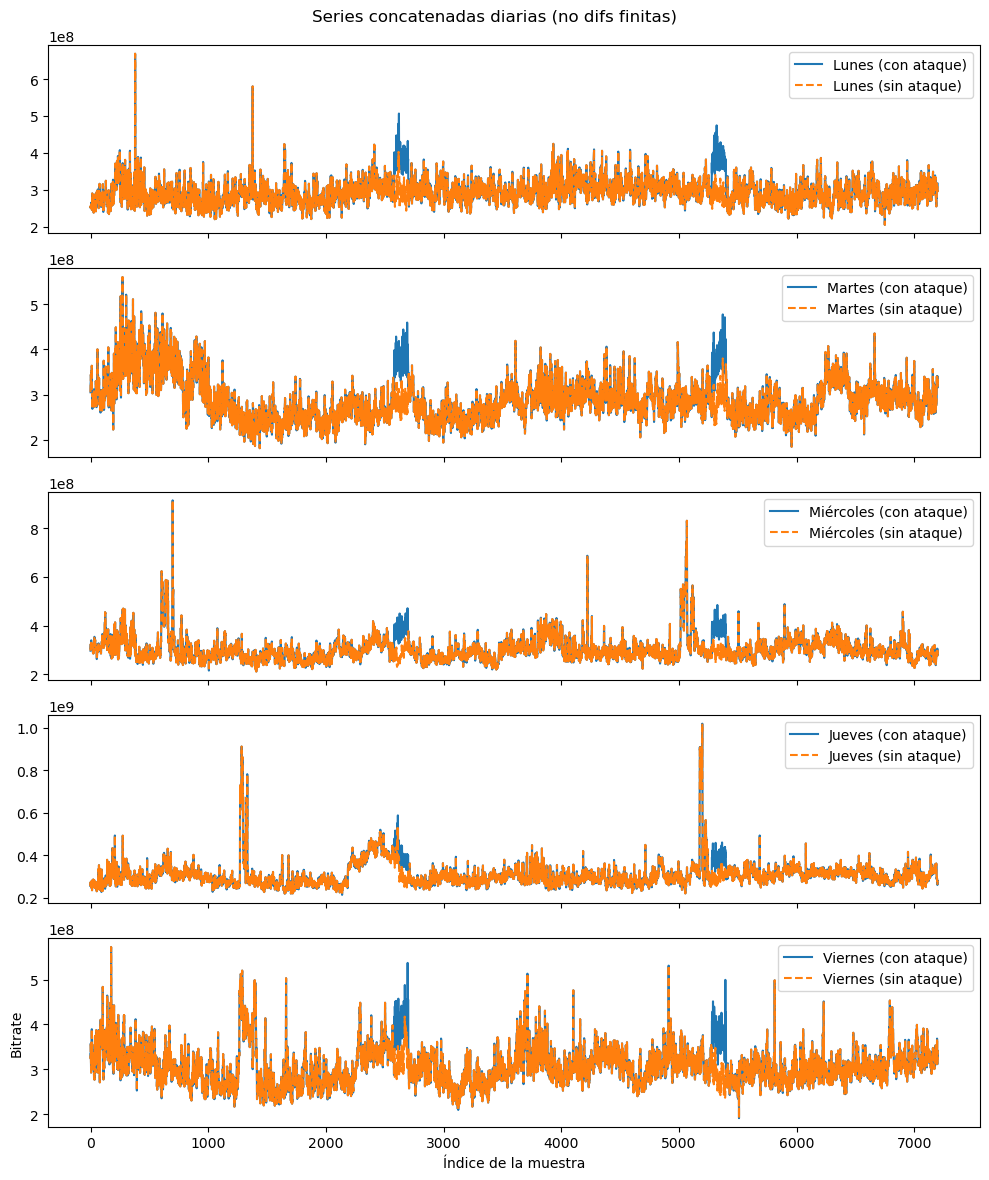

In [5]:
# CONCATENAR ARCHIVOS
archivos_lunes = [
    'series_originales/bitrate_original_lun_0.csv',
    #'series_ataque65/bitrate_attack_lun0.csv',
    #'ataque_rampa/bitrate_interval_lun0.csv',
    #'ataque_meseta/bitrate_interval_lun0.csv',
    'series_originales/bitrate_original_lun_1.csv',
    #'series_ataque65/bitrate_attack_lun1.csv',
    #'ataque_rampa/bitrate_interval_lun1.csv',
    #'ataque_meseta/bitrate_interval_lun1.csv',
    #'series_originales/bitrate_original_lun_2.csv',
    'series_ataque65/bitrate_attack_lun2.csv',
    #'ataque_rampa/bitrate_interval_lun2.csv',
    #'ataque_meseta/bitrate_interval_lun2.csv',
    'series_originales/bitrate_original_lun_3.csv',
    #'series_ataque65/bitrate_attack_lun3.csv',
    #'ataque_rampa/bitrate_interval_lun3.csv',
    #'ataque_meseta/bitrate_interval_lun3.csv',
    'series_originales/bitrate_original_lun_4.csv',
    #'series_ataque65/bitrate_attack_lun4.csv',
    #'ataque_rampa/bitrate_interval_lun4.csv',
    #'ataque_meseta/bitrate_interval_lun4.csv',
    #'series_originales/bitrate_original_lun_5.csv',
    'series_ataque65/bitrate_attack_lun5.csv',
    #'ataque_rampa/bitrate_interval_lun5.csv',
    #'ataque_meseta/bitrate_interval_lun5.csv',
    'series_originales/bitrate_original_lun_6.csv',
    #'series_ataque65/bitrate_attack_lun6.csv',
    #'ataque_rampa/bitrate_interval_lun6.csv',
    #'ataque_meseta/bitrate_interval_lun6.csv',
    'series_originales/bitrate_original_lun_7.csv'
    #'series_ataque65/bitrate_attack_lun7.csv'
    #'ataque_rampa/bitrate_interval_lun7.csv'
    #'ataque_meseta/bitrate_interval_lun7.csv'
]


archivos_lunes_sin_ataque = [
    'series_originales/bitrate_original_lun_0.csv',
    'series_originales/bitrate_original_lun_1.csv',
    'series_originales/bitrate_original_lun_2.csv',
    'series_originales/bitrate_original_lun_3.csv',
    'series_originales/bitrate_original_lun_4.csv',
    'series_originales/bitrate_original_lun_5.csv',
    'series_originales/bitrate_original_lun_6.csv',
    'series_originales/bitrate_original_lun_7.csv'
]

archivos_martes = [
    'series_originales/bitrate_original_mar_0.csv',
    #'series_ataque65/bitrate_attack_mar0.csv',
    #'ataque_rampa/bitrate_interval_mar0.csv',
    #'ataque_meseta/bitrate_interval_mar0.csv',
    'series_originales/bitrate_original_mar_1.csv',
    #'series_ataque65/bitrate_attack_mar1.csv',
    #'ataque_rampa/bitrate_interval_mar1.csv',
    #'ataque_meseta/bitrate_interval_mar1.csv',
    #'series_originales/bitrate_original_mar_2.csv',
    'series_ataque65/bitrate_attack_mar2.csv',
    #'ataque_rampa/bitrate_interval_mar2.csv',
    #'ataque_meseta/bitrate_interval_mar2.csv',
    'series_originales/bitrate_original_mar_3.csv',
    #'series_ataque65/bitrate_attack_mar3.csv',
    #'ataque_rampa/bitrate_interval_mar3.csv',
    #'ataque_meseta/bitrate_interval_mar3.csv',
    'series_originales/bitrate_original_mar_4.csv',
    #'series_ataque65/bitrate_attack_mar4.csv',
    #'ataque_rampa/bitrate_interval_mar4.csv',
    #'ataque_meseta/bitrate_interval_mar4.csv',
    #'series_originales/bitrate_original_mar_5.csv',
    'series_ataque65/bitrate_attack_mar5.csv',
    #'ataque_rampa/bitrate_interval_mar5.csv',
    #'ataque_meseta/bitrate_interval_mar5.csv',
    'series_originales/bitrate_original_mar_6.csv',
    #'series_ataque65/bitrate_attack_mar6.csv',
    #'ataque_rampa/bitrate_interval_mar6.csv',
    #'ataque_meseta/bitrate_interval_mar6.csv',
    'series_originales/bitrate_original_mar_7.csv'
    #'series_ataque65/bitrate_attack_mar7.csv'
    #'ataque_rampa/bitrate_interval_mar7.csv'
    #'ataque_meseta/bitrate_interval_mar7.csv'
]

archivos_martes_sin_ataque = [
    'series_originales/bitrate_original_mar_0.csv',
    'series_originales/bitrate_original_mar_1.csv',
    'series_originales/bitrate_original_mar_2.csv',
    'series_originales/bitrate_original_mar_3.csv',
    'series_originales/bitrate_original_mar_4.csv',
    'series_originales/bitrate_original_mar_5.csv',
    'series_originales/bitrate_original_mar_6.csv',
    'series_originales/bitrate_original_mar_7.csv'
]

archivos_miercoles = [
    'series_originales/bitrate_original_mie_0.csv',
    #'series_ataque65/bitrate_attack_mie0.csv',
    #'ataque_rampa/bitrate_interval_mie0.csv',
    #'ataque_meseta/bitrate_interval_mie0.csv',
    'series_originales/bitrate_original_mie_1.csv',
    #'series_ataque65/bitrate_attack_mie1.csv',
    #'ataque_rampa/bitrate_interval_mie1.csv',
    #'ataque_meseta/bitrate_interval_mie1.csv',
    #'series_originales/bitrate_original_mie_2.csv',
    'series_ataque65/bitrate_attack_mie2.csv',
    #'ataque_rampa/bitrate_interval_mie2.csv',
    #'ataque_meseta/bitrate_interval_mie2.csv',
    'series_originales/bitrate_original_mie_3.csv',
    #'series_ataque65/bitrate_attack_mie3.csv',
    #'ataque_rampa/bitrate_interval_mie3.csv',
    #'ataque_meseta/bitrate_interval_mie3.csv',
    'series_originales/bitrate_original_mie_4.csv',
    #'series_ataque65/bitrate_attack_mie4.csv',
    #'ataque_rampa/bitrate_interval_mie4.csv',
    #'ataque_meseta/bitrate_interval_mie4.csv',
    #'series_originales/bitrate_original_mie_5.csv',
    'series_ataque65/bitrate_attack_mie5.csv',
    #'ataque_rampa/bitrate_interval_mie5.csv',
    #'ataque_meseta/bitrate_interval_mie5.csv',
    'series_originales/bitrate_original_mie_6.csv',
    #'series_ataque65/bitrate_attack_mie6.csv',
    #'ataque_rampa/bitrate_interval_mie6.csv',
    #'ataque_meseta/bitrate_interval_mie6.csv',
    'series_originales/bitrate_original_mie_7.csv'
    #'series_ataque65/bitrate_attack_mie7.csv'
    #'ataque_rampa/bitrate_interval_mie7.csv'
    #'ataque_meseta/bitrate_interval_mie7.csv'
]

archivos_miercoles_sin_ataque = [
    'series_originales/bitrate_original_mie_0.csv',
    'series_originales/bitrate_original_mie_1.csv',
    'series_originales/bitrate_original_mie_2.csv',
    'series_originales/bitrate_original_mie_3.csv',
    'series_originales/bitrate_original_mie_4.csv',
    'series_originales/bitrate_original_mie_5.csv',
    'series_originales/bitrate_original_mie_6.csv',
    'series_originales/bitrate_original_mie_7.csv'
]

archivos_jueves = [
    'series_originales/bitrate_original_jue_0.csv',
    #'series_ataque65/bitrate_attack_jue0.csv',
    #'ataque_rampa/bitrate_interval_jue0.csv',
    #'ataque_meseta/bitrate_interval_jue0.csv',
    'series_originales/bitrate_original_jue_1.csv',
    #'series_ataque65/bitrate_attack_jue1.csv',
    #'ataque_rampa/bitrate_interval_jue1.csv',
    #'ataque_meseta/bitrate_interval_jue1.csv',
    #'series_originales/bitrate_original_jue_2.csv',
    'series_ataque65/bitrate_attack_jue2.csv',
    #'ataque_rampa/bitrate_interval_jue2.csv',
    #'ataque_meseta/bitrate_interval_jue2.csv',
    'series_originales/bitrate_original_jue_3.csv',
    #'series_ataque65/bitrate_attack_jue3.csv',
    #'ataque_rampa/bitrate_interval_jue3.csv',
    #'ataque_meseta/bitrate_interval_jue3.csv',
    'series_originales/bitrate_original_jue_4.csv',
    #'series_ataque65/bitrate_attack_jue4.csv',
    #'ataque_rampa/bitrate_interval_jue4.csv',
    #'ataque_meseta/bitrate_interval_jue4.csv',
    #'series_originales/bitrate_original_jue_5.csv',
    'series_ataque65/bitrate_attack_jue5.csv',
    #'ataque_rampa/bitrate_interval_jue5.csv',
    #'ataque_meseta/bitrate_interval_jue5.csv',
    'series_originales/bitrate_original_jue_6.csv',
    #'series_ataque65/bitrate_attack_jue6.csv',
    #'ataque_rampa/bitrate_interval_jue6.csv',
    #'ataque_meseta/bitrate_interval_jue6.csv',
    'series_originales/bitrate_original_jue_7.csv'
    #'series_ataque65/bitrate_attack_jue7.csv'
    #'ataque_rampa/bitrate_interval_jue7.csv'
    #'ataque_meseta/bitrate_interval_jue7.csv'
]

archivos_jueves_sin_ataque = [
    'series_originales/bitrate_original_jue_0.csv',
    'series_originales/bitrate_original_jue_1.csv',
    'series_originales/bitrate_original_jue_2.csv',
    'series_originales/bitrate_original_jue_3.csv',
    'series_originales/bitrate_original_jue_4.csv',
    'series_originales/bitrate_original_jue_5.csv',
    'series_originales/bitrate_original_jue_6.csv',
    'series_originales/bitrate_original_jue_7.csv'
]

archivos_viernes = [
    'series_originales/bitrate_original_vie_0.csv',
    #'series_ataque65/bitrate_attack_vie0.csv',
    #'ataque_rampa/bitrate_interval_vie0.csv',
    #'ataque_meseta/bitrate_interval_vie0.csv',
    'series_originales/bitrate_original_vie_1.csv',
    #'series_ataque65/bitrate_attack_vie1.csv',
    #'ataque_rampa/bitrate_interval_vie1.csv',
    #'ataque_meseta/bitrate_interval_vie1.csv',
    #'series_originales/bitrate_original_vie_2.csv',
    'series_ataque65/bitrate_attack_vie2.csv',
    #'ataque_rampa/bitrate_interval_vie2.csv',
    #'ataque_meseta/bitrate_interval_vie2.csv',
    'series_originales/bitrate_original_vie_3.csv',
    #'series_ataque65/bitrate_attack_vie3.csv',
    #'ataque_rampa/bitrate_interval_vie3.csv',
    #'ataque_meseta/bitrate_interval_vie3.csv',
    'series_originales/bitrate_original_vie_4.csv',
    #'series_ataque65/bitrate_attack_vie4.csv',
    #'ataque_rampa/bitrate_interval_vie4.csv',
    #'ataque_meseta/bitrate_interval_vie4.csv',
    #'series_originales/bitrate_original_vie_5.csv',
    'series_ataque65/bitrate_attack_vie5.csv',
    #'ataque_rampa/bitrate_interval_vie5.csv',
    #'ataque_meseta/bitrate_interval_vie5.csv',
    'series_originales/bitrate_original_vie_6.csv',
    #'series_ataque65/bitrate_attack_vie6.csv',
    #'ataque_rampa/bitrate_interval_vie6.csv',
    #'ataque_meseta/bitrate_interval_vie6.csv',
    'series_originales/bitrate_original_vie_7.csv'
    #'series_ataque65/bitrate_attack_vie7.csv'
    #'ataque_rampa/bitrate_interval_vie7.csv'
    #'ataque_meseta/bitrate_interval_vie7.csv'
]

archivos_viernes_sin_ataque = [
    'series_originales/bitrate_original_vie_0.csv',
    'series_originales/bitrate_original_vie_1.csv',
    'series_originales/bitrate_original_vie_2.csv',
    'series_originales/bitrate_original_vie_3.csv',
    'series_originales/bitrate_original_vie_4.csv',
    'series_originales/bitrate_original_vie_5.csv',
    'series_originales/bitrate_original_vie_6.csv',
    'series_originales/bitrate_original_vie_7.csv'
]



# Leer y concatenar directamente
df_concatenado_lunes = pd.concat([pd.read_csv(archivo1, header=None) for archivo1 in archivos_lunes], axis=0, ignore_index=True)
df_concatenado_martes = pd.concat([pd.read_csv(archivo2, header=None) for archivo2 in archivos_martes], axis=0, ignore_index=True)
df_concatenado_miercoles = pd.concat([pd.read_csv(archivo3, header=None) for archivo3 in archivos_miercoles], axis=0, ignore_index=True)
df_concatenado_jueves = pd.concat([pd.read_csv(archivo4, header=None) for archivo4 in archivos_jueves], axis=0, ignore_index=True)
df_concatenado_viernes = pd.concat([pd.read_csv(archivo5, header=None) for archivo5 in archivos_viernes], axis=0, ignore_index=True)


#print('1', df_concatenado_lunes)
#print('2', df_concatenado_martes)
#print('3', df_concatenado_miercoles)
#print('4', df_concatenado_jueves)
#print('5', df_concatenado_viernes)


df_concatenado_lunes_diff = df_concatenado_lunes.diff()
df_concatenado_martes_diff = df_concatenado_martes.diff()
df_concatenado_miercoles_diff = df_concatenado_miercoles.diff()
df_concatenado_jueves_diff = df_concatenado_jueves.diff()
df_concatenado_viernes_diff = df_concatenado_viernes.diff()




df_concatenado_lunes_sin_ataque = pd.concat([pd.read_csv(archivo11, header=None) for archivo11 in archivos_lunes_sin_ataque], axis=0, ignore_index=True)
df_concatenado_martes_sin_ataque = pd.concat([pd.read_csv(archivo22, header=None) for archivo22 in archivos_martes_sin_ataque], axis=0, ignore_index=True)
df_concatenado_miercoles_sin_ataque = pd.concat([pd.read_csv(archivo33, header=None) for archivo33 in archivos_miercoles_sin_ataque], axis=0, ignore_index=True)
df_concatenado_jueves_sin_ataque = pd.concat([pd.read_csv(archivo44, header=None) for archivo44 in archivos_jueves_sin_ataque], axis=0, ignore_index=True)
df_concatenado_viernes_sin_ataque = pd.concat([pd.read_csv(archivo55, header=None) for archivo55 in archivos_viernes_sin_ataque], axis=0, ignore_index=True)

df_concatenado_lunes_sin_ataque_diff = df_concatenado_lunes_sin_ataque.diff()
df_concatenado_martes_sin_ataque_diff = df_concatenado_martes_sin_ataque.diff()
df_concatenado_miercoles_sin_ataque_diff = df_concatenado_miercoles_sin_ataque.diff()
df_concatenado_jueves_sin_ataque_diff = df_concatenado_jueves_sin_ataque.diff()
df_concatenado_viernes_sin_ataque_diff = df_concatenado_viernes_sin_ataque.diff()


def diff_series(df, method=0):
    if method == 0:
        x_t = df.diff().dropna().reset_index(drop=True, inplace=False)
    elif method == 1:
        x_t = pd.Series([-1/2*df.iloc[i-1] + 1/2*df.iloc[i+1] for i in range(1, len(df)-1)])
    elif method == 2: #Filtro de diferencia central con mayor precision
        x_t = pd.Series([1/12 * df.iloc[i-2] - 2/3 * df.iloc[i-1] + 2/3 * df.iloc[i+1] - 1/12 * df.iloc[i+2] for i in range(2, len(df)-2)])
    elif method == 3: #prewitt
        x_t = pd.Series([-1*df.iloc[i-1] + 1*df.iloc[i+1] for i in range(1, len(df)-1)])
    elif method == 4: #scharr
        x_t = pd.Series([-3*df.iloc[i-1] + 3*df.iloc[i+1] for i in range(1, len(df)-1)])
    return x_t

#df_concatenado_lunes_pd = pd.Series(df_concatenado_lunes)
#df_concatenado_lunes_sin_ataque_pd = pd.Series(df_concatenado_lunes_sin_ataque)

serie_lunes = df_concatenado_lunes.iloc[:, 0]
serie_lunes_sin_ataque = df_concatenado_lunes_sin_ataque.iloc[:, 0]

serie_martes = df_concatenado_martes.iloc[:, 0]
serie_martes_sin_ataque = df_concatenado_martes_sin_ataque.iloc[:, 0]

serie_miercoles = df_concatenado_miercoles.iloc[:, 0]
serie_miercoles_sin_ataque = df_concatenado_miercoles_sin_ataque.iloc[:, 0]

serie_jueves = df_concatenado_jueves.iloc[:, 0]
serie_jueves_sin_ataque = df_concatenado_jueves_sin_ataque.iloc[:, 0]

serie_viernes = df_concatenado_viernes.iloc[:, 0]
serie_viernes_sin_ataque = df_concatenado_viernes_sin_ataque.iloc[:, 0]

#LUNES
#method=0
#diff_series_lunes = diff_series(df_concatenado_lunes, method=0)
#diff_series_lunes_sin_ataque = diff_series(df_concatenado_lunes_sin_ataque, method=0)

#method=1/2/3/4
#diff_series_lunes = diff_series(serie_lunes, method=4)
#diff_series_lunes_sin_ataque = diff_series(serie_lunes_sin_ataque, method=4)

#MARTES
#method=0
#diff_series_martes = diff_series(df_concatenado_martes, method=0)
#diff_series_martes_sin_ataque = diff_series(df_concatenado_martes_sin_ataque, method=0)

#method=1/2/3/4
#diff_series_martes = diff_series(serie_martes, method=4)
#diff_series_martes_sin_ataque = diff_series(serie_martes_sin_ataque, method=4)

#MIERCOLES
#method=0
#diff_series_miercoles = diff_series(df_concatenado_miercoles, method=0)
#diff_series_miercoles_sin_ataque = diff_series(df_concatenado_miercoles_sin_ataque, method=0)

#method=1/2/3/4
#diff_series_miercoles = diff_series(serie_miercoles, method=4)
#diff_series_miercoles_sin_ataque = diff_series(serie_miercoles_sin_ataque, method=4)

#JUEVES
#method=0
#diff_series_jueves = diff_series(df_concatenado_jueves, method=0)
#diff_series_jueves_sin_ataque = diff_series(df_concatenado_jueves_sin_ataque, method=0)

#method=1/2/3/4
#diff_series_jueves = diff_series(serie_jueves, method=4)
#diff_series_jueves_sin_ataque = diff_series(serie_jueves_sin_ataque, method=4)

#VIERNES
#method=0
#diff_series_viernes = diff_series(df_concatenado_viernes, method=0)
#diff_series_viernes_sin_ataque = diff_series(df_concatenado_viernes_sin_ataque, method=0)

#method=1/2/3/4
#diff_series_viernes = diff_series(serie_viernes, method=4)
#diff_series_viernes_sin_ataque = diff_series(serie_viernes_sin_ataque, method=4)



#---------------------------------------------------------------------------

# Guardar el archivo concatenado si lo necesitas
#df_concatenado_lunes_diff.to_csv('series_concatenadas/archivo_concatenado_lunes_diff.csv', index=False, header=False)
#df_concatenado_martes_diff.to_csv('series_concatenadas/archivo_concatenado_martes_diff.csv', index=False, header=False)
#df_concatenado_miercoles_diff.to_csv('series_concatenadas/archivo_concatenado_miercoles_diff.csv', index=False, header=False)
#df_concatenado_jueves_diff.to_csv('series_concatenadas/archivo_concatenado_jueves_diff.csv', index=False, header=False)
#df_concatenado_viernes_diff.to_csv('series_concatenadas/archivo_concatenado_viernes_diff.csv', index=False, header=False)

#CASO ATAQUE RAMPA
#df_concatenado_lunes_diff.to_csv('series_concatenadas_rampa/archivo_concatenado_lunes_diff.csv', index=False, header=False)
#df_concatenado_martes_diff.to_csv('series_concatenadas_rampa/archivo_concatenado_martes_diff.csv', index=False, header=False)
#df_concatenado_miercoles_diff.to_csv('series_concatenadas_rampa/archivo_concatenado_miercoles_diff.csv', index=False, header=False)
#df_concatenado_jueves_diff.to_csv('series_concatenadas_rampa/archivo_concatenado_jueves_diff.csv', index=False, header=False)
#df_concatenado_viernes_diff.to_csv('series_concatenadas_rampa/archivo_concatenado_viernes_diff.csv', index=False, header=False)

#CASO ATAQUE MESETA
#df_concatenado_lunes_diff.to_csv('series_concatenadas_meseta/archivo_concatenado_lunes_diff.csv', index=False, header=False)
#df_concatenado_martes_diff.to_csv('series_concatenadas_meseta/archivo_concatenado_martes_diff.csv', index=False, header=False)
#df_concatenado_miercoles_diff.to_csv('series_concatenadas_meseta/archivo_concatenado_miercoles_diff.csv', index=False, header=False)
#df_concatenado_jueves_diff.to_csv('series_concatenadas_meseta/archivo_concatenado_jueves_diff.csv', index=False, header=False)
#df_concatenado_viernes_diff.to_csv('series_concatenadas_meseta/archivo_concatenado_viernes_diff.csv', index=False, header=False)

#CASO DIFF_SERIES
#diff_series_lunes.to_csv('series_concatenadas/archivo_concatenado_lunes_diff_m4.csv', index=False, header=False)
#diff_series_martes.to_csv('series_concatenadas/archivo_concatenado_martes_diff_m4.csv', index=False, header=False)
#diff_series_miercoles.to_csv('series_concatenadas/archivo_concatenado_miercoles_diff_m4.csv', index=False, header=False)
#diff_series_jueves.to_csv('series_concatenadas/archivo_concatenado_jueves_diff_m4.csv', index=False, header=False)
#diff_series_viernes.to_csv('series_concatenadas/archivo_concatenado_viernes_diff_m4.csv', index=False, header=False)


#GUARDAR SERIES SIN ATAQUE
#df_concatenado_lunes_sin_ataque_diff.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_lunes_sin_ataque_diff.csv', index=False, header=False)
#df_concatenado_martes_sin_ataque_diff.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_martes_sin_ataque_diff.csv', index=False, header=False)
#df_concatenado_miercoles_sin_ataque_diff.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque_diff.csv', index=False, header=False)
#df_concatenado_jueves_sin_ataque_diff.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_jueves_sin_ataque_diff.csv', index=False, header=False)
#df_concatenado_viernes_sin_ataque_diff.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_viernes_sin_ataque_diff.csv', index=False, header=False)

#CASO DIFF_SERIES SIN ATAQUE
#diff_series_lunes_sin_ataque.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_lunes_sin_ataque_diff_m4.csv', index=False, header=False)
#diff_series_martes_sin_ataque.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_martes_sin_ataque_diff_m4.csv', index=False, header=False)
#diff_series_miercoles_sin_ataque.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque_diff_m4.csv', index=False, header=False)
#diff_series_jueves_sin_ataque.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_jueves_sin_ataque_diff_m4.csv', index=False, header=False)
#diff_series_viernes_sin_ataque.to_csv('series_concatenadas_sin_ataque/archivo_concatenado_viernes_sin_ataque_diff_m4.csv', index=False, header=False)


import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# Lunes: graficar serie con ataque y sin ataque
axes[0].plot(df_concatenado_lunes[0], label='Lunes (con ataque)')
axes[0].plot(df_concatenado_lunes_sin_ataque[0], label='Lunes (sin ataque)', linestyle='--')
axes[0].legend()

# Martes
axes[1].plot(df_concatenado_martes[0], label='Martes (con ataque)')
axes[1].plot(df_concatenado_martes_sin_ataque[0], label='Martes (sin ataque)', linestyle='--')
axes[1].legend()

# Miércoles
axes[2].plot(df_concatenado_miercoles[0], label='Miércoles (con ataque)')
axes[2].plot(df_concatenado_miercoles_sin_ataque[0], label='Miércoles (sin ataque)', linestyle='--')
axes[2].legend()

# Jueves
axes[3].plot(df_concatenado_jueves[0], label='Jueves (con ataque)')
axes[3].plot(df_concatenado_jueves_sin_ataque[0], label='Jueves (sin ataque)', linestyle='--')
axes[3].legend()

# Viernes
axes[4].plot(df_concatenado_viernes[0], label='Viernes (con ataque)')
axes[4].plot(df_concatenado_viernes_sin_ataque[0], label='Viernes (sin ataque)', linestyle='--')
axes[4].legend()

plt.xlabel('Índice de la muestra')
plt.ylabel('Bitrate')
plt.suptitle('Series concatenadas diarias (no difs finitas)')
plt.tight_layout()
plt.show()


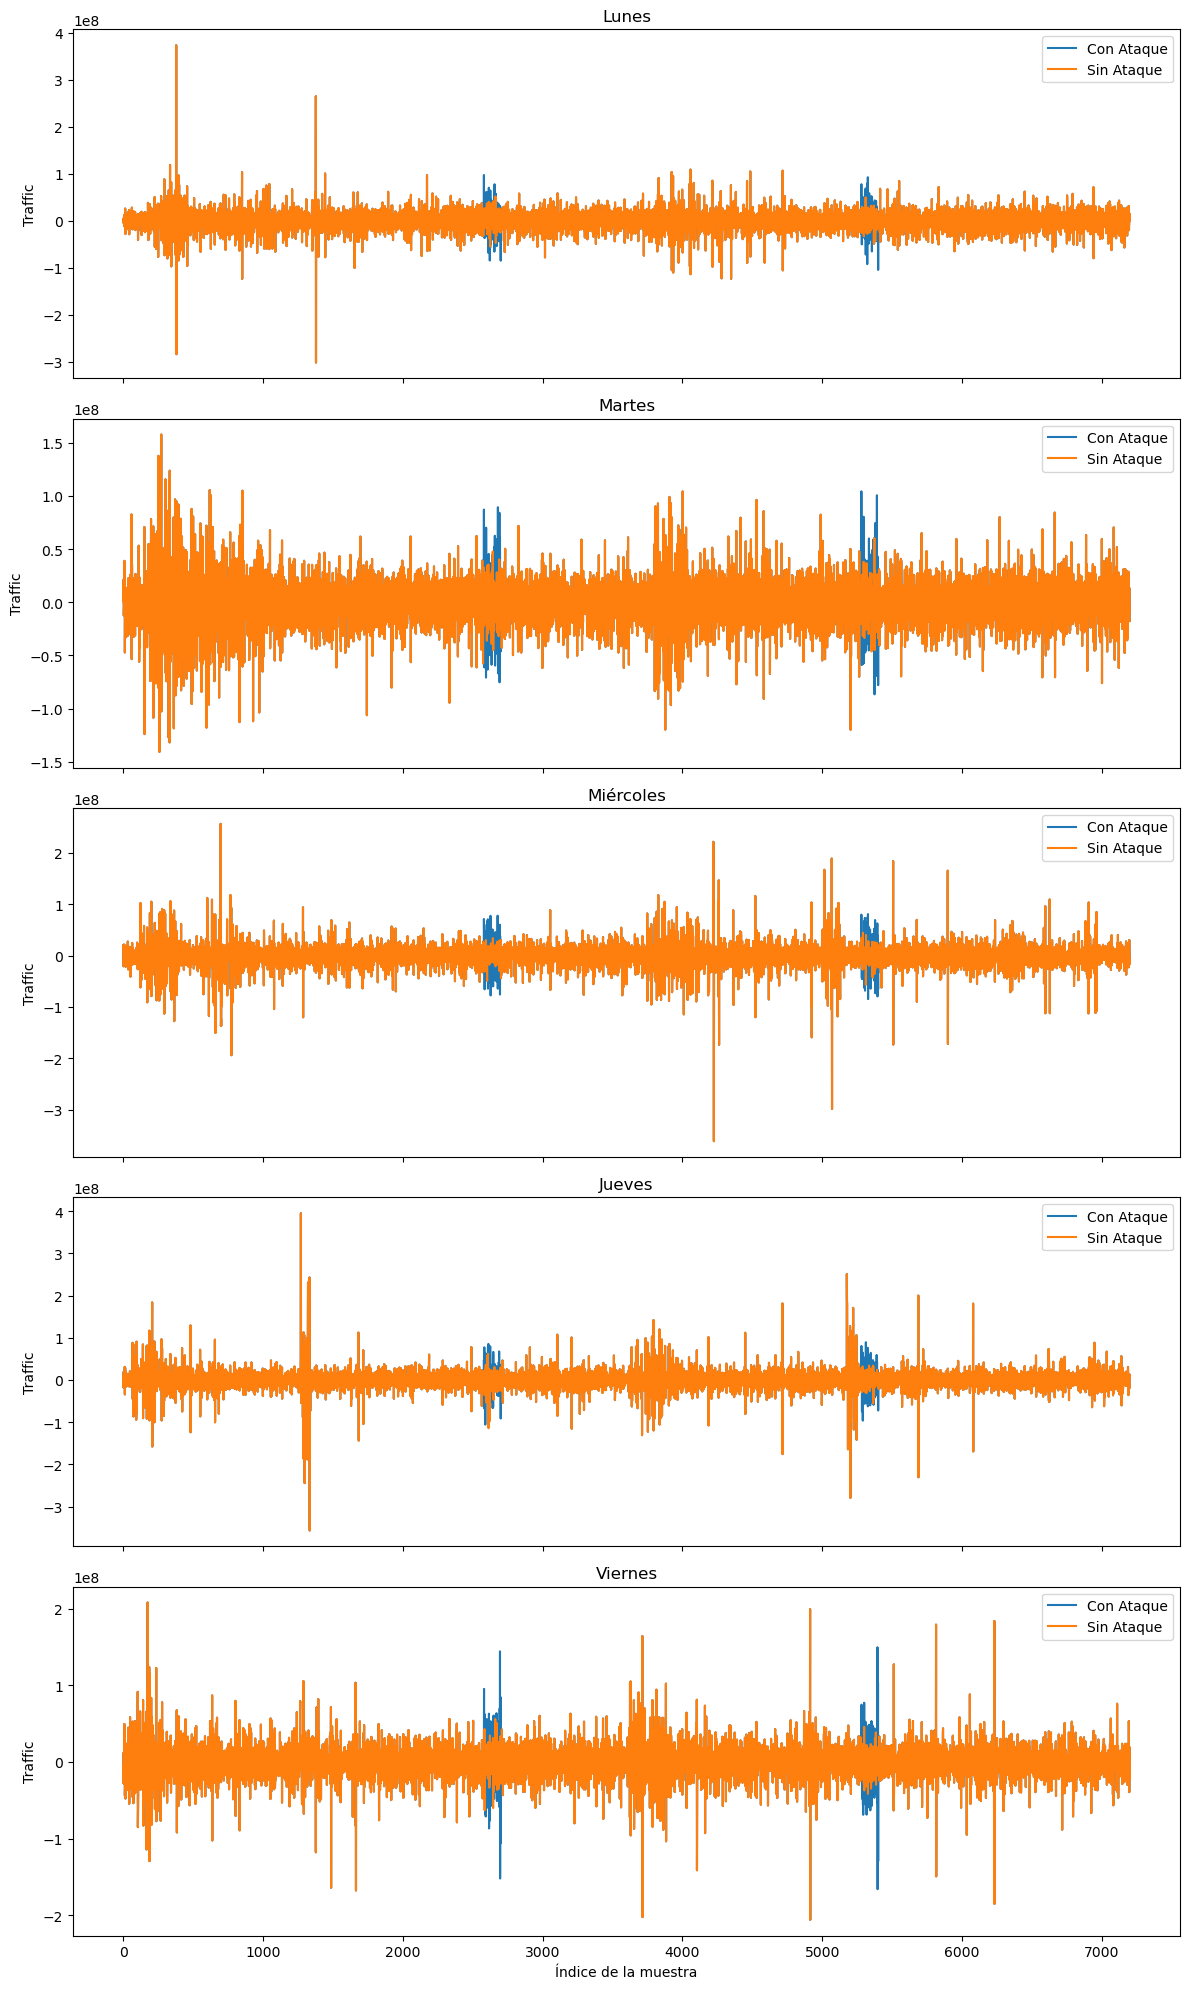

In [6]:
data_atk_lunes_completo = pd.read_csv(f'series_concatenadas/archivo_concatenado_lunes_diff.csv', header=None, names=['traffic'])
data_atk_martes_completo = pd.read_csv(f'series_concatenadas/archivo_concatenado_martes_diff.csv', header=None, names=['traffic'])
data_atk_miercoles_completo = pd.read_csv(f'series_concatenadas/archivo_concatenado_miercoles_diff.csv', header=None, names=['traffic'])
data_atk_jueves_completo = pd.read_csv(f'series_concatenadas/archivo_concatenado_jueves_diff.csv', header=None, names=['traffic'])
data_atk_viernes_completo = pd.read_csv(f'series_concatenadas/archivo_concatenado_viernes_diff.csv', header=None, names=['traffic'])

#CASO ATAQUE RAMPA
#data_atk_lunes_completo = pd.read_csv(f'series_concatenadas_rampa/archivo_concatenado_lunes_diff.csv', header=None, names=['traffic'])
#data_atk_martes_completo = pd.read_csv(f'series_concatenadas_rampa/archivo_concatenado_martes_diff.csv', header=None, names=['traffic'])
#data_atk_miercoles_completo = pd.read_csv(f'series_concatenadas_rampa/archivo_concatenado_miercoles_diff.csv', header=None, names=['traffic'])
#data_atk_jueves_completo = pd.read_csv(f'series_concatenadas_rampa/archivo_concatenado_jueves_diff.csv', header=None, names=['traffic'])
#data_atk_viernes_completo = pd.read_csv(f'series_concatenadas_rampa/archivo_concatenado_viernes_diff.csv', header=None, names=['traffic'])

data_atk_lunes_completo_sin_ataque = pd.read_csv(f'series_concatenadas_sin_ataque/archivo_concatenado_lunes_sin_ataque_diff.csv', header=None, names=['traffic'])
data_atk_martes_completo_sin_ataque = pd.read_csv(f'series_concatenadas_sin_ataque/archivo_concatenado_martes_sin_ataque_diff.csv', header=None, names=['traffic'])
data_atk_miercoles_completo_sin_ataque = pd.read_csv(f'series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque_diff.csv', header=None, names=['traffic'])
data_atk_jueves_completo_sin_ataque = pd.read_csv(f'series_concatenadas_sin_ataque/archivo_concatenado_jueves_sin_ataque_diff.csv', header=None, names=['traffic'])
data_atk_viernes_completo_sin_ataque = pd.read_csv(f'series_concatenadas_sin_ataque/archivo_concatenado_viernes_sin_ataque_diff.csv', header=None, names=['traffic'])


import matplotlib.pyplot as plt

#Diferencias finitas de archivos concatenados

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20), sharex=True)

# Lunes
axes[0].plot(data_atk_lunes_completo['traffic'], label='Con Ataque')
axes[0].plot(data_atk_lunes_completo_sin_ataque['traffic'], label='Sin Ataque')
axes[0].set_title('Lunes')
axes[0].set_ylabel('Traffic')
axes[0].legend()

# Martes
axes[1].plot(data_atk_martes_completo['traffic'], label='Con Ataque')
axes[1].plot(data_atk_martes_completo_sin_ataque['traffic'], label='Sin Ataque')
axes[1].set_title('Martes')
axes[1].set_ylabel('Traffic')
axes[1].legend()

# Miércoles
axes[2].plot(data_atk_miercoles_completo['traffic'], label='Con Ataque')
axes[2].plot(data_atk_miercoles_completo_sin_ataque['traffic'], label='Sin Ataque')
axes[2].set_title('Miércoles')
axes[2].set_ylabel('Traffic')
axes[2].legend()

# Jueves
axes[3].plot(data_atk_jueves_completo['traffic'], label='Con Ataque')
axes[3].plot(data_atk_jueves_completo_sin_ataque['traffic'], label='Sin Ataque')
axes[3].set_title('Jueves')
axes[3].set_ylabel('Traffic')
axes[3].legend()

# Viernes
axes[4].plot(data_atk_viernes_completo['traffic'], label='Con Ataque')
axes[4].plot(data_atk_viernes_completo_sin_ataque['traffic'], label='Sin Ataque')
axes[4].set_title('Viernes')
axes[4].set_ylabel('Traffic')
axes[4].set_xlabel('Índice de la muestra')
axes[4].legend()

plt.tight_layout()
plt.show()

In [7]:


ventanas_deslizantes_lunes = []
ventanas_deslizantes_martes = []
ventanas_deslizantes_miercoles = []
ventanas_deslizantes_jueves = []
ventanas_deslizantes_viernes = []

ventana_tamaño = 900  
#paso = 60  # 1 minuto en muestras
paso = 1

print(data_atk_lunes_completo)
print(len(data_atk_lunes_completo))
print(len(data_atk_martes_completo))
print(len(data_atk_miercoles_completo))
print(len(data_atk_jueves_completo))
print(len(data_atk_viernes_completo))

# Crear ventanas deslizantes
for inicio in range(0, len(data_atk_lunes_completo) - ventana_tamaño + 1, paso):
    ventana_lunes = data_atk_lunes_completo['traffic'][inicio:inicio + ventana_tamaño].values
    ventanas_deslizantes_lunes.append(ventana_lunes)

    ventana_martes = data_atk_martes_completo['traffic'][inicio:inicio + ventana_tamaño].values
    ventanas_deslizantes_martes.append(ventana_martes)

    ventana_miercoles = data_atk_miercoles_completo['traffic'][inicio:inicio + ventana_tamaño].values
    ventanas_deslizantes_miercoles.append(ventana_miercoles)

    ventana_jueves = data_atk_jueves_completo['traffic'][inicio:inicio + ventana_tamaño].values
    ventanas_deslizantes_jueves.append(ventana_jueves)

    ventana_viernes = data_atk_viernes_completo['traffic'][inicio:inicio + ventana_tamaño].values
    ventanas_deslizantes_viernes.append(ventana_viernes)

# Convertir las ventanas en un DataFrame para análisis posterior
ventanas_deslizantes_lunes_df = pd.DataFrame(ventanas_deslizantes_lunes)
ventanas_deslizantes_martes_df = pd.DataFrame(ventanas_deslizantes_martes)
ventanas_deslizantes_miercoles_df = pd.DataFrame(ventanas_deslizantes_miercoles)
ventanas_deslizantes_jueves_df = pd.DataFrame(ventanas_deslizantes_jueves)
ventanas_deslizantes_viernes_df = pd.DataFrame(ventanas_deslizantes_viernes)



from scipy.stats import kurtosis, skew

media_ventanas_lunes = []
std_ventanas_lunes = []
curtosis_ventanas_lunes = []
skew_ventanas_lunes = []

media_ventanas_martes = []
std_ventanas_martes = []
curtosis_ventanas_martes = []
skew_ventanas_martes = []

media_ventanas_miercoles = []
std_ventanas_miercoles = []
curtosis_ventanas_miercoles = []
skew_ventanas_miercoles = []

media_ventanas_jueves = []
std_ventanas_jueves = []
curtosis_ventanas_jueves = []
skew_ventanas_jueves = []

media_ventanas_viernes = []
std_ventanas_viernes = []
curtosis_ventanas_viernes = []
skew_ventanas_viernes = []

for ventana_lunes in ventanas_deslizantes_lunes:
    media_ventanas_lunes.append(np.mean(ventana_lunes))
    std_ventanas_lunes.append(np.std(ventana_lunes))
    curtosis_ventanas_lunes.append(kurtosis(ventana_lunes))
    skew_ventanas_lunes.append(skew(ventana_lunes))

for ventana_martes in ventanas_deslizantes_martes:
    media_ventanas_martes.append(np.mean(ventana_martes))
    std_ventanas_martes.append(np.std(ventana_martes))
    curtosis_ventanas_martes.append(kurtosis(ventana_martes))
    skew_ventanas_martes.append(skew(ventana_martes))

for ventana_miercoles in ventanas_deslizantes_miercoles:
    media_ventanas_miercoles.append(np.mean(ventana_miercoles))
    std_ventanas_miercoles.append(np.std(ventana_miercoles))
    curtosis_ventanas_miercoles.append(kurtosis(ventana_miercoles))
    skew_ventanas_miercoles.append(skew(ventana_miercoles))

for ventana_jueves in ventanas_deslizantes_jueves:
    media_ventanas_jueves.append(np.mean(ventana_jueves))
    std_ventanas_jueves.append(np.std(ventana_jueves))
    curtosis_ventanas_jueves.append(kurtosis(ventana_jueves))
    skew_ventanas_jueves.append(skew(ventana_jueves))

for ventana_viernes in ventanas_deslizantes_viernes:
    media_ventanas_viernes.append(np.mean(ventana_viernes))
    std_ventanas_viernes.append(np.std(ventana_viernes))
    curtosis_ventanas_viernes.append(kurtosis(ventana_viernes))
    skew_ventanas_viernes.append(skew(ventana_viernes))

# Crear un DataFrame para resumir las estadísticas
estadisticas_df_lunes = pd.DataFrame({
    'Media': media_ventanas_lunes,
    'Desviación Estándar': std_ventanas_lunes,
    'Curtosis': curtosis_ventanas_lunes,
    'Skew': skew_ventanas_lunes
})

estadisticas_df_martes = pd.DataFrame({
    'Media': media_ventanas_martes,
    'Desviación Estándar': std_ventanas_martes,
    'Curtosis': curtosis_ventanas_martes,
    'Skew': skew_ventanas_martes
})

estadisticas_df_miercoles = pd.DataFrame({
    'Media': media_ventanas_miercoles,
    'Desviación Estándar': std_ventanas_miercoles,
    'Curtosis': curtosis_ventanas_miercoles,
    'Skew': skew_ventanas_miercoles
})

estadisticas_df_jueves = pd.DataFrame({
    'Media': media_ventanas_jueves,
    'Desviación Estándar': std_ventanas_jueves,
    'Curtosis': curtosis_ventanas_jueves,
    'Skew': skew_ventanas_jueves
})

estadisticas_df_viernes = pd.DataFrame({
    'Media': media_ventanas_viernes,
    'Desviación Estándar': std_ventanas_viernes,
    'Curtosis': curtosis_ventanas_viernes,
    'Skew': skew_ventanas_viernes
})



#---------------------LO MISMO PERO SIN ATAQUE------------------------------

ventanas_deslizantes_lunes_sin_ataque = []
ventanas_deslizantes_martes_sin_ataque = []
ventanas_deslizantes_miercoles_sin_ataque = []
ventanas_deslizantes_jueves_sin_ataque = []
ventanas_deslizantes_viernes_sin_ataque = []

ventana_tamaño = 900  
#paso = 60  # 1 minuto en muestras
paso = 1

print(len(data_atk_lunes_completo_sin_ataque))
print(len(data_atk_martes_completo_sin_ataque))
print(len(data_atk_miercoles_completo_sin_ataque))
print(len(data_atk_jueves_completo_sin_ataque))
print(len(data_atk_viernes_completo_sin_ataque))

# Crear ventanas deslizantes
for inicio_sin_ataque in range(0, len(data_atk_lunes_completo_sin_ataque) - ventana_tamaño + 1, paso):
    ventana_lunes_sin_ataque = data_atk_lunes_completo_sin_ataque['traffic'][inicio_sin_ataque:inicio_sin_ataque + ventana_tamaño].values
    ventanas_deslizantes_lunes_sin_ataque.append(ventana_lunes_sin_ataque)

    ventana_martes_sin_ataque = data_atk_martes_completo_sin_ataque['traffic'][inicio_sin_ataque:inicio_sin_ataque + ventana_tamaño].values
    ventanas_deslizantes_martes_sin_ataque.append(ventana_martes_sin_ataque)

    ventana_miercoles_sin_ataque = data_atk_miercoles_completo_sin_ataque['traffic'][inicio_sin_ataque:inicio_sin_ataque + ventana_tamaño].values
    ventanas_deslizantes_miercoles_sin_ataque.append(ventana_miercoles_sin_ataque)

    ventana_jueves_sin_ataque = data_atk_jueves_completo_sin_ataque['traffic'][inicio_sin_ataque:inicio_sin_ataque + ventana_tamaño].values
    ventanas_deslizantes_jueves_sin_ataque.append(ventana_jueves_sin_ataque)

    ventana_viernes_sin_ataque = data_atk_viernes_completo_sin_ataque['traffic'][inicio_sin_ataque:inicio_sin_ataque + ventana_tamaño].values
    ventanas_deslizantes_viernes_sin_ataque.append(ventana_viernes_sin_ataque)

# Convertir las ventanas en un DataFrame para análisis posterior
ventanas_deslizantes_lunes_df_sin_ataque = pd.DataFrame(ventanas_deslizantes_lunes_sin_ataque)
ventanas_deslizantes_martes_df_sin_ataque = pd.DataFrame(ventanas_deslizantes_martes_sin_ataque)
ventanas_deslizantes_miercoles_df_sin_ataque = pd.DataFrame(ventanas_deslizantes_miercoles_sin_ataque)
ventanas_deslizantes_jueves_df_sin_ataque = pd.DataFrame(ventanas_deslizantes_jueves_sin_ataque)
ventanas_deslizantes_viernes_df_sin_ataque = pd.DataFrame(ventanas_deslizantes_viernes_sin_ataque)



media_ventanas_lunes_sin_ataque = []
std_ventanas_lunes_sin_ataque = []
curtosis_ventanas_lunes_sin_ataque = []
skew_ventanas_lunes_sin_ataque = []

media_ventanas_martes_sin_ataque = []
std_ventanas_martes_sin_ataque = []
curtosis_ventanas_martes_sin_ataque = []
skew_ventanas_martes_sin_ataque = []

media_ventanas_miercoles_sin_ataque = []
std_ventanas_miercoles_sin_ataque = []
curtosis_ventanas_miercoles_sin_ataque = []
skew_ventanas_miercoles_sin_ataque = []

media_ventanas_jueves_sin_ataque = []
std_ventanas_jueves_sin_ataque = []
curtosis_ventanas_jueves_sin_ataque = []
skew_ventanas_jueves_sin_ataque = []

media_ventanas_viernes_sin_ataque = []
std_ventanas_viernes_sin_ataque = []
curtosis_ventanas_viernes_sin_ataque = []
skew_ventanas_viernes_sin_ataque = []

for ventana_lunes_sin_ataque in ventanas_deslizantes_lunes_sin_ataque:
    media_ventanas_lunes_sin_ataque.append(np.mean(ventana_lunes_sin_ataque))
    std_ventanas_lunes_sin_ataque.append(np.std(ventana_lunes_sin_ataque))
    curtosis_ventanas_lunes_sin_ataque.append(kurtosis(ventana_lunes_sin_ataque))
    skew_ventanas_lunes_sin_ataque.append(skew(ventana_lunes_sin_ataque))

for ventana_martes_sin_ataque in ventanas_deslizantes_martes_sin_ataque:
    media_ventanas_martes_sin_ataque.append(np.mean(ventana_martes_sin_ataque))
    std_ventanas_martes_sin_ataque.append(np.std(ventana_martes_sin_ataque))
    curtosis_ventanas_martes_sin_ataque.append(kurtosis(ventana_martes_sin_ataque))
    skew_ventanas_martes_sin_ataque.append(skew(ventana_martes_sin_ataque))

for ventana_miercoles_sin_ataque in ventanas_deslizantes_miercoles_sin_ataque:
    media_ventanas_miercoles_sin_ataque.append(np.mean(ventana_miercoles_sin_ataque))
    std_ventanas_miercoles_sin_ataque.append(np.std(ventana_miercoles_sin_ataque))
    curtosis_ventanas_miercoles_sin_ataque.append(kurtosis(ventana_miercoles_sin_ataque))
    skew_ventanas_miercoles_sin_ataque.append(skew(ventana_miercoles_sin_ataque))

for ventana_jueves_sin_ataque in ventanas_deslizantes_jueves_sin_ataque:
    media_ventanas_jueves_sin_ataque.append(np.mean(ventana_jueves_sin_ataque))
    std_ventanas_jueves_sin_ataque.append(np.std(ventana_jueves_sin_ataque))
    curtosis_ventanas_jueves_sin_ataque.append(kurtosis(ventana_jueves_sin_ataque))
    skew_ventanas_jueves_sin_ataque.append(skew(ventana_jueves_sin_ataque))

for ventana_viernes_sin_ataque in ventanas_deslizantes_viernes_sin_ataque:
    media_ventanas_viernes_sin_ataque.append(np.mean(ventana_viernes_sin_ataque))
    std_ventanas_viernes_sin_ataque.append(np.std(ventana_viernes_sin_ataque))
    curtosis_ventanas_viernes_sin_ataque.append(kurtosis(ventana_viernes_sin_ataque))
    skew_ventanas_viernes_sin_ataque.append(skew(ventana_viernes_sin_ataque))

# Crear un DataFrame para resumir las estadísticas
estadisticas_df_lunes_sin_ataque = pd.DataFrame({
    'Media': media_ventanas_lunes_sin_ataque,
    'Desviación Estándar': std_ventanas_lunes_sin_ataque,
    'Curtosis': curtosis_ventanas_lunes_sin_ataque,
    'Skew': skew_ventanas_lunes_sin_ataque
})

estadisticas_df_martes_sin_ataque = pd.DataFrame({
    'Media': media_ventanas_martes_sin_ataque,
    'Desviación Estándar': std_ventanas_martes_sin_ataque,
    'Curtosis': curtosis_ventanas_martes_sin_ataque,
    'Skew': skew_ventanas_martes_sin_ataque
})

estadisticas_df_miercoles_sin_ataque = pd.DataFrame({
    'Media': media_ventanas_miercoles_sin_ataque,
    'Desviación Estándar': std_ventanas_miercoles_sin_ataque,
    'Curtosis': curtosis_ventanas_miercoles_sin_ataque,
    'Skew': skew_ventanas_miercoles_sin_ataque
})

estadisticas_df_jueves_sin_ataque = pd.DataFrame({
    'Media': media_ventanas_jueves_sin_ataque,
    'Desviación Estándar': std_ventanas_jueves_sin_ataque,
    'Curtosis': curtosis_ventanas_jueves_sin_ataque,
    'Skew': skew_ventanas_jueves_sin_ataque
})

estadisticas_df_viernes_sin_ataque = pd.DataFrame({
    'Media': media_ventanas_viernes_sin_ataque,
    'Desviación Estándar': std_ventanas_viernes_sin_ataque,
    'Curtosis': curtosis_ventanas_viernes_sin_ataque,
    'Skew': skew_ventanas_viernes_sin_ataque
})



           traffic
0              NaN
1     2.835880e+06
2    -5.035274e+06
3     3.312972e+06
4    -3.687872e+06
...            ...
7195 -2.456081e+06
7196  3.430025e+06
7197 -1.833887e+06
7198  1.479321e+07
7199  5.763909e+06

[7200 rows x 1 columns]
7200
7200
7200
7200
7200
7200
7200
7200
7200
7200


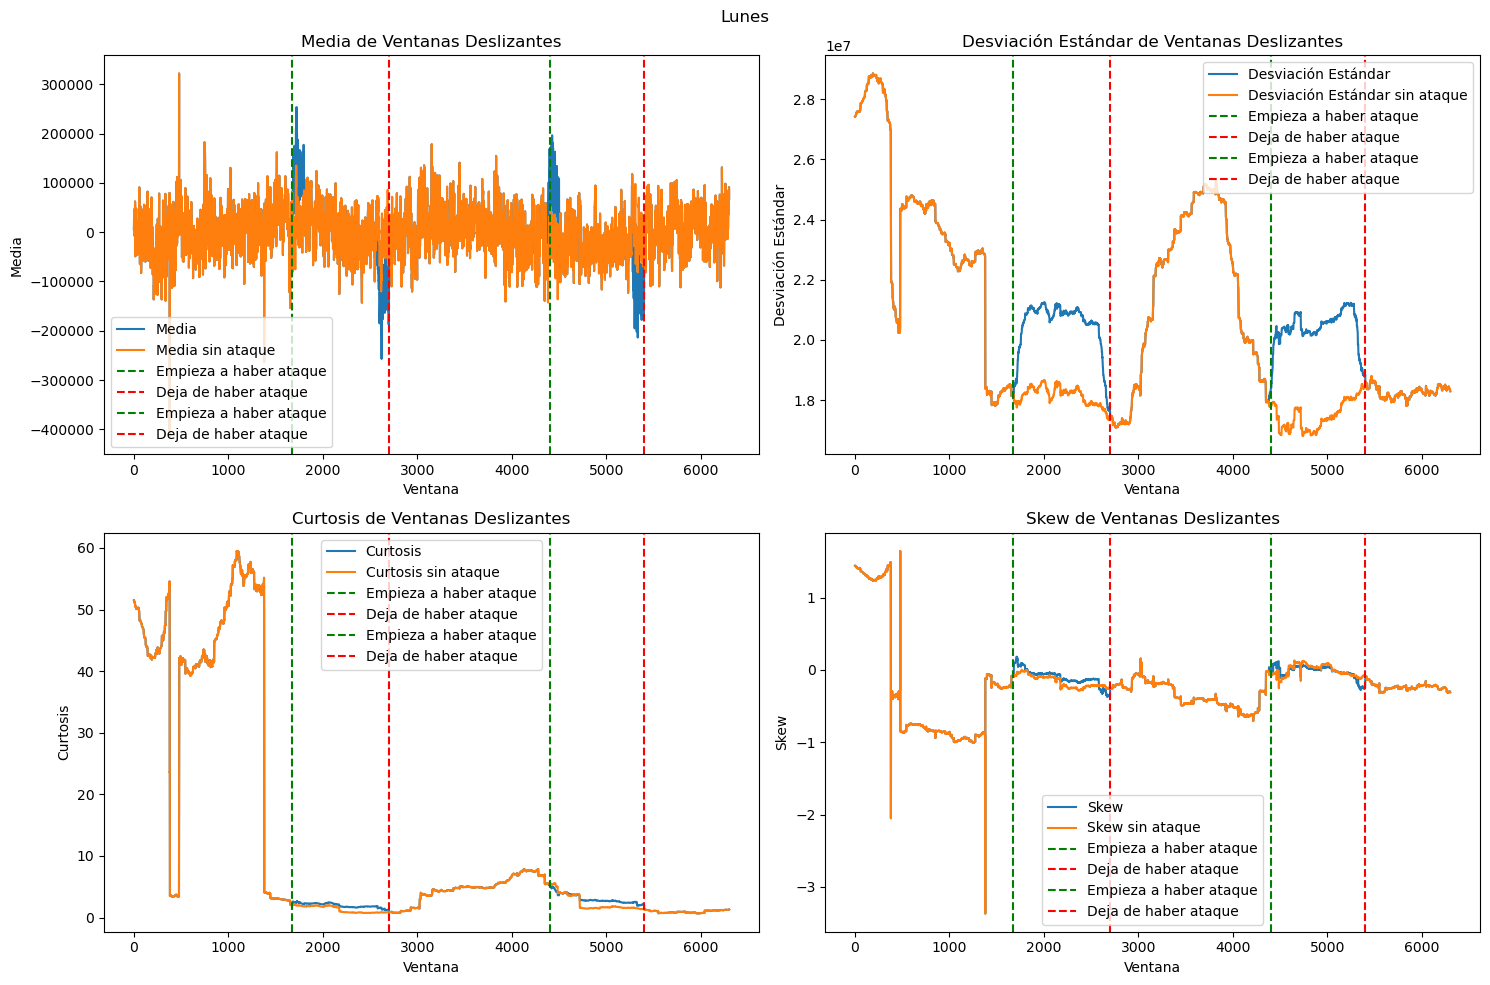

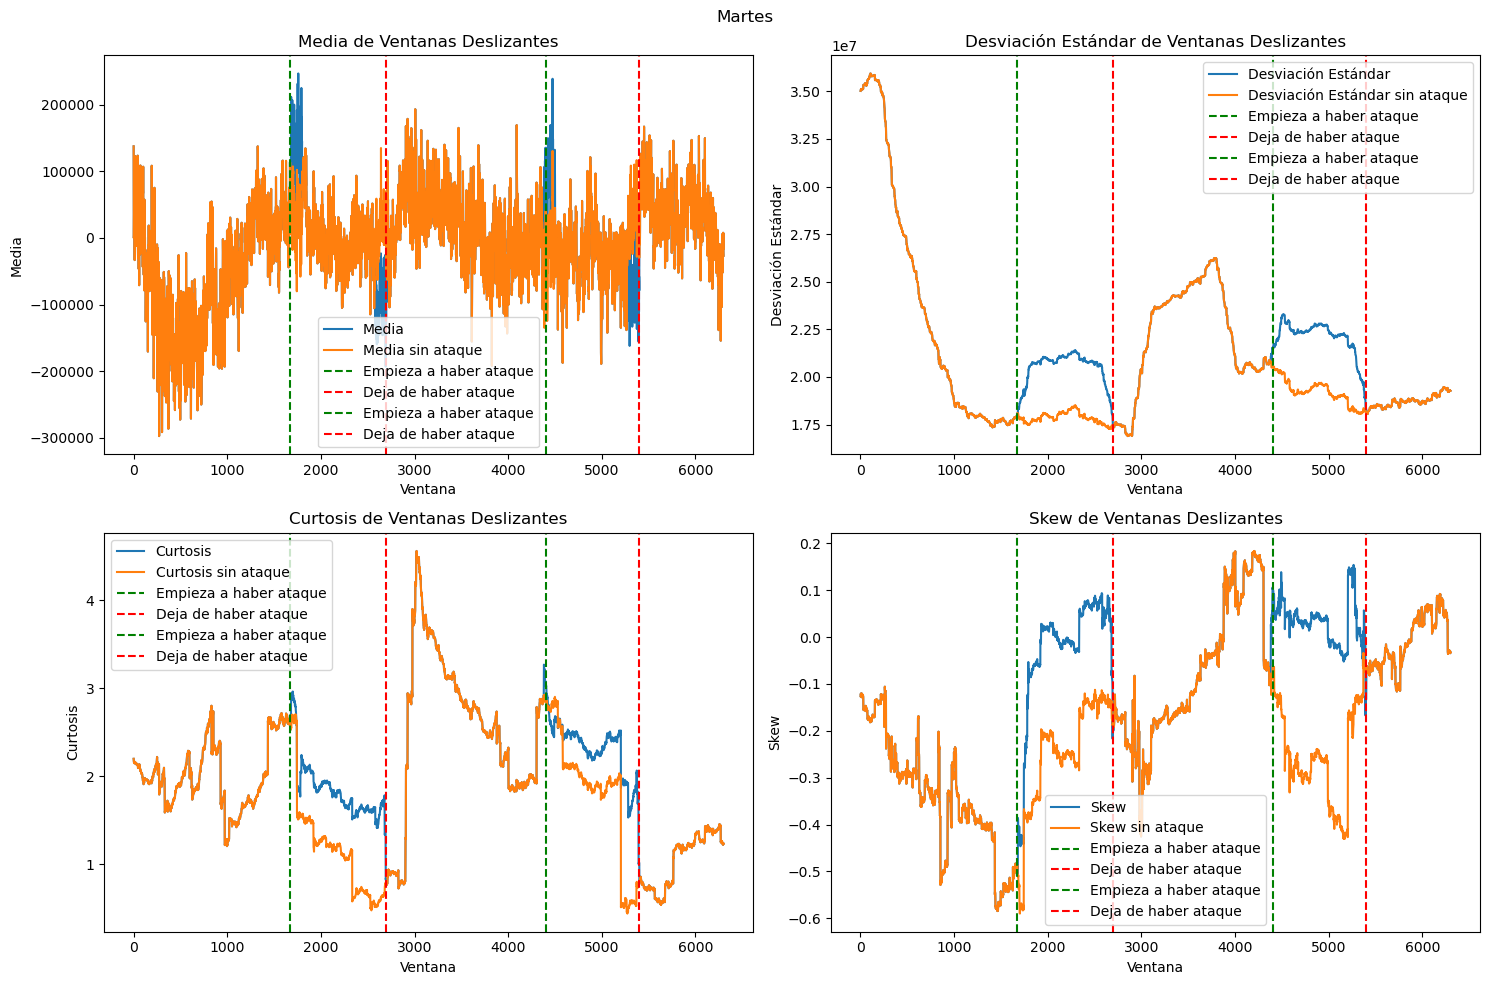

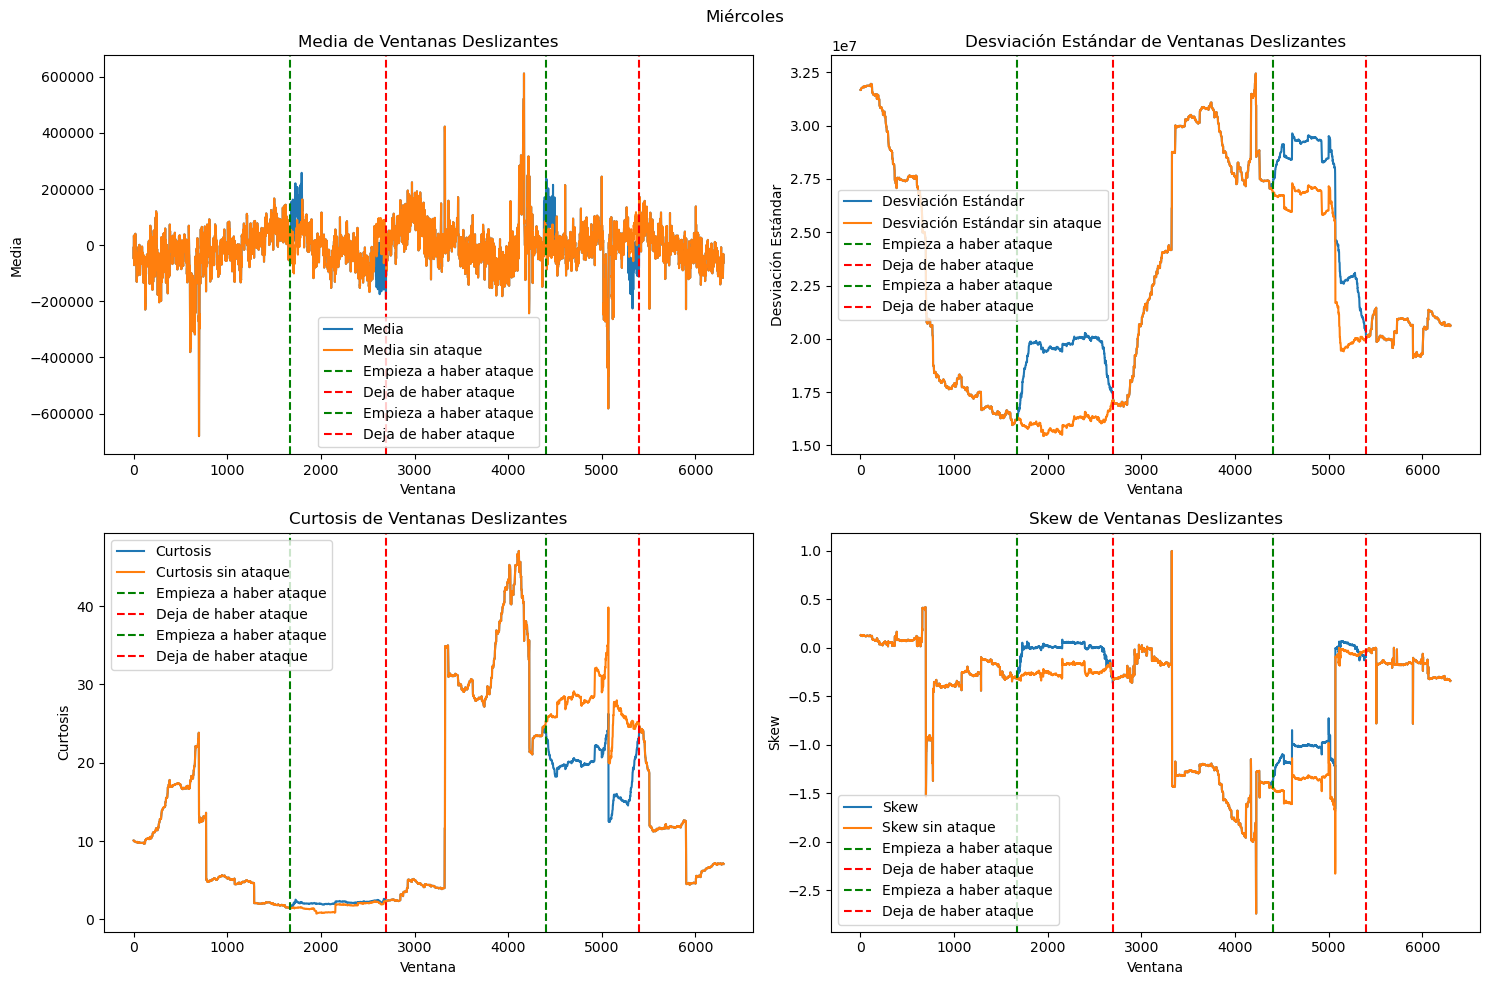

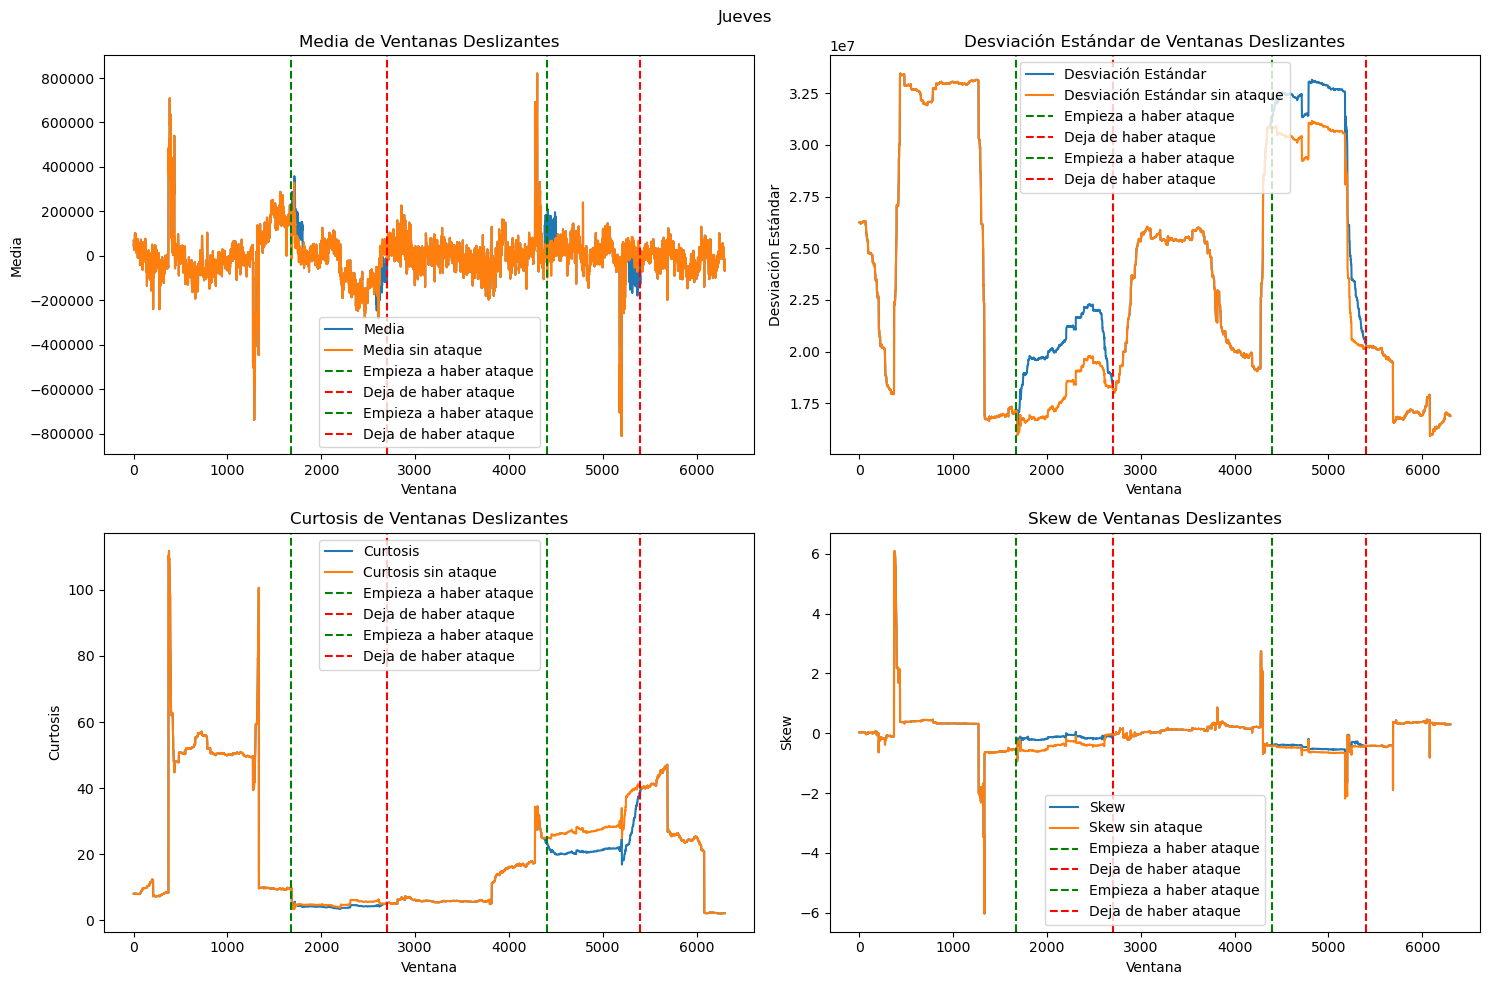

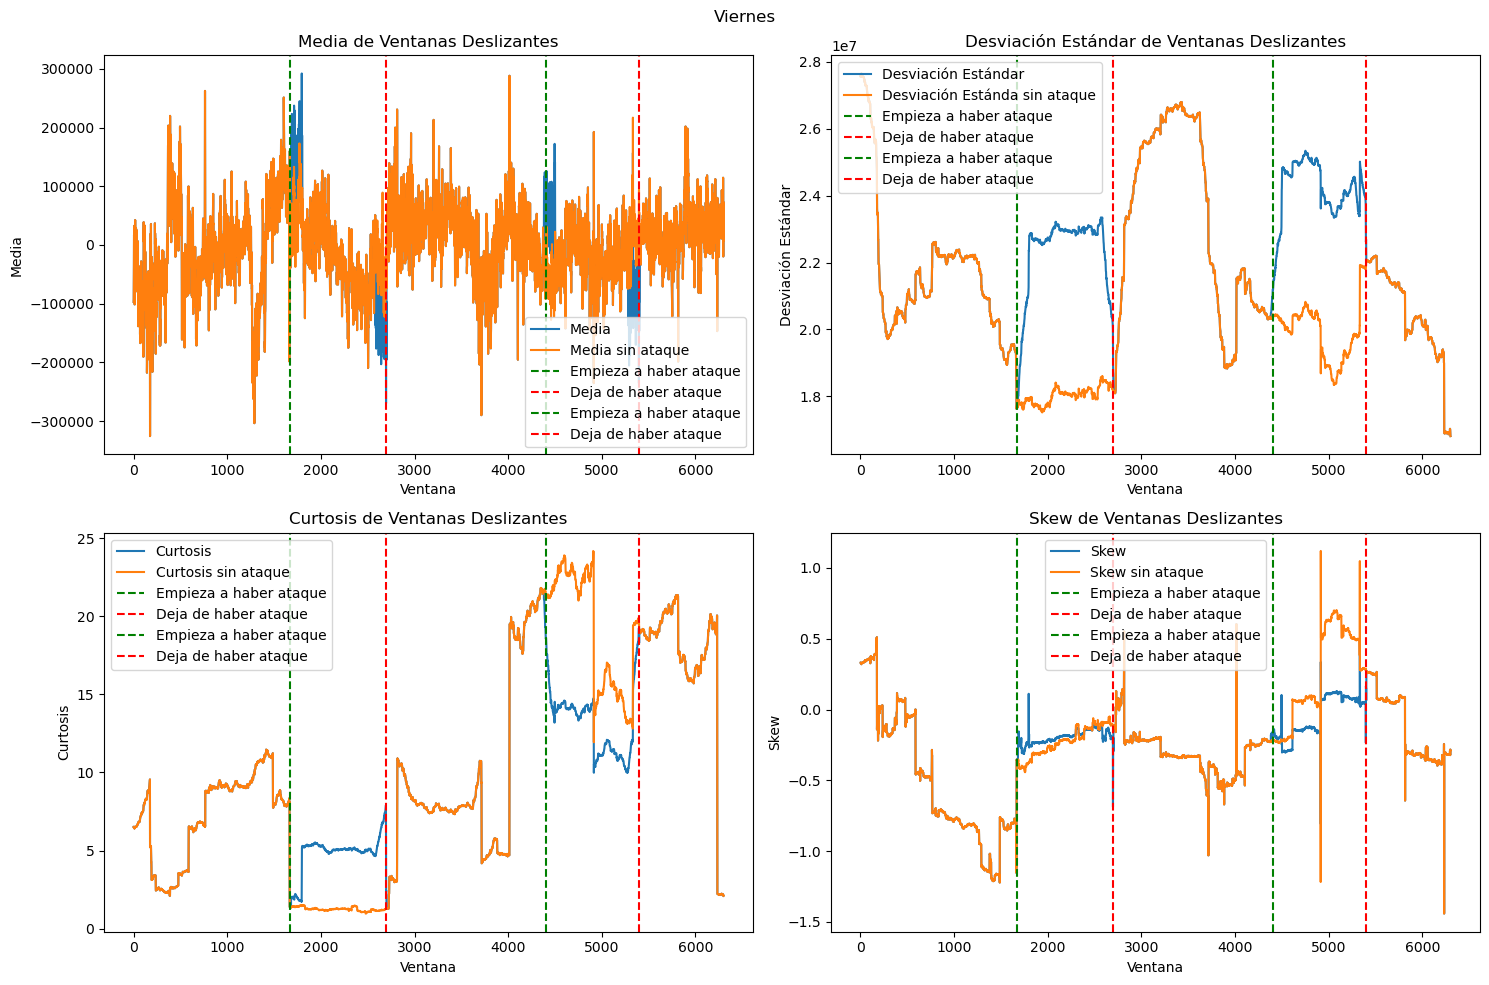

In [8]:
#Representaciones
plt.figure(figsize=(15, 10))

# Media
plt.subplot(2, 2, 1)
plt.plot(media_ventanas_lunes, label='Media')
plt.plot(media_ventanas_lunes_sin_ataque, label='Media sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
#plt.axvline(x=inicio_ataque, color='red', linestyle='--', label='Empieza a haber ataque')
#plt.axvline(x=fin_ataque, color='green', linestyle='--', label='Deja de haber ataque')
plt.title('Media de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Media')
plt.legend()

# Desviación Estándar
plt.subplot(2, 2, 2)
#plt.plot(std_ventanas_lunes, label='Desviación Estándar', color='orange')
plt.plot(std_ventanas_lunes, label='Desviación Estándar')
plt.plot(std_ventanas_lunes_sin_ataque, label='Desviación Estándar sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
#plt.axvline(x=inicio_ataque, color='red', linestyle='--', label='Empieza a haber ataque')
#plt.axvline(x=fin_ataque, color='green', linestyle='--', label='Deja de haber ataque')
plt.title('Desviación Estándar de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Desviación Estándar')
plt.legend()

# Curtosis
plt.subplot(2, 2, 3)
plt.plot(curtosis_ventanas_lunes, label='Curtosis')
plt.plot(curtosis_ventanas_lunes_sin_ataque, label='Curtosis sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Curtosis de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Curtosis')
plt.legend()

# Skew
plt.subplot(2, 2, 4)
plt.plot(skew_ventanas_lunes, label='Skew')
plt.plot(skew_ventanas_lunes_sin_ataque, label='Skew sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Skew de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Skew')
plt.legend()

plt.suptitle('Lunes')


plt.tight_layout()
plt.show()


#-----Martes------


plt.figure(figsize=(15, 10))

# Media
plt.subplot(2, 2, 1)
plt.plot(media_ventanas_martes, label='Media')
plt.plot(media_ventanas_martes_sin_ataque, label='Media sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Media de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Media')
plt.legend()

# Desviación Estándar
plt.subplot(2, 2, 2)
plt.plot(std_ventanas_martes, label='Desviación Estándar')
plt.plot(std_ventanas_martes_sin_ataque, label='Desviación Estándar sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Desviación Estándar de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Desviación Estándar')
plt.legend()

# Curtosis
plt.subplot(2, 2, 3)
plt.plot(curtosis_ventanas_martes, label='Curtosis')
plt.plot(curtosis_ventanas_martes_sin_ataque, label='Curtosis sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Curtosis de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Curtosis')
plt.legend()

# Skew
plt.subplot(2, 2, 4)
plt.plot(skew_ventanas_martes, label='Skew')
plt.plot(skew_ventanas_martes_sin_ataque, label='Skew sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Skew de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Skew')
plt.legend()

plt.suptitle('Martes')

plt.tight_layout()
plt.show()


#-----Miercoles------


plt.figure(figsize=(15, 10))

# Media
plt.subplot(2, 2, 1)
plt.plot(media_ventanas_miercoles, label='Media')
plt.plot(media_ventanas_miercoles_sin_ataque, label='Media sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Media de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Media')
plt.legend()

# Desviación Estándar
plt.subplot(2, 2, 2)
plt.plot(std_ventanas_miercoles, label='Desviación Estándar')
plt.plot(std_ventanas_miercoles_sin_ataque, label='Desviación Estándar sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Desviación Estándar de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Desviación Estándar')
plt.legend()

# Curtosis
plt.subplot(2, 2, 3)
plt.plot(curtosis_ventanas_miercoles, label='Curtosis')
plt.plot(curtosis_ventanas_miercoles_sin_ataque, label='Curtosis sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Curtosis de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Curtosis')
plt.legend()

# Skew
plt.subplot(2, 2, 4)
plt.plot(skew_ventanas_miercoles, label='Skew')
plt.plot(skew_ventanas_miercoles_sin_ataque, label='Skew sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Skew de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Skew')
plt.legend()

plt.suptitle('Miércoles')

#plt.savefig("figuras_memoria/parametros.pdf")
#plt.savefig("figuras_memoria/parametros.svg")

plt.tight_layout()
plt.show()


#-----Jueves------


plt.figure(figsize=(15, 10))

# Media
plt.subplot(2, 2, 1)
plt.plot(media_ventanas_jueves, label='Media')
plt.plot(media_ventanas_jueves_sin_ataque, label='Media sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Media de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Media')
plt.legend()

# Desviación Estándar
plt.subplot(2, 2, 2)
plt.plot(std_ventanas_jueves, label='Desviación Estándar')
plt.plot(std_ventanas_jueves_sin_ataque, label='Desviación Estándar sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Desviación Estándar de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Desviación Estándar')
plt.legend()

# Curtosis
plt.subplot(2, 2, 3)
plt.plot(curtosis_ventanas_jueves, label='Curtosis')
plt.plot(curtosis_ventanas_jueves_sin_ataque, label='Curtosis sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Curtosis de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Curtosis')
plt.legend()

# Skew
plt.subplot(2, 2, 4)
plt.plot(skew_ventanas_jueves, label='Skew')
plt.plot(skew_ventanas_jueves_sin_ataque, label='Skew sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Skew de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Skew')
plt.legend()

plt.suptitle('Jueves')


plt.tight_layout()
plt.show()


#-----Viernes------


plt.figure(figsize=(15, 10))

# Media
plt.subplot(2, 2, 1)
plt.plot(media_ventanas_viernes, label='Media')
plt.plot(media_ventanas_viernes_sin_ataque, label='Media sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Media de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Media')
plt.legend()

# Desviación Estándar
plt.subplot(2, 2, 2)
plt.plot(std_ventanas_viernes, label='Desviación Estándar')
plt.plot(std_ventanas_viernes_sin_ataque, label='Desviación Estánda sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Desviación Estándar de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Desviación Estándar')
plt.legend()

# Curtosis
plt.subplot(2, 2, 3)
plt.plot(curtosis_ventanas_viernes, label='Curtosis')
plt.plot(curtosis_ventanas_viernes_sin_ataque, label='Curtosis sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Curtosis de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Curtosis')
plt.legend()

# Skew
plt.subplot(2, 2, 4)
plt.plot(skew_ventanas_viernes, label='Skew')
plt.plot(skew_ventanas_viernes_sin_ataque, label='Skew sin ataque')
plt.axvline(x=1675, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4400, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5399, color='red', linestyle='--', label='Deja de haber ataque')
plt.title('Skew de Ventanas Deslizantes')
plt.xlabel('Ventana')
plt.ylabel('Skew')
plt.legend()

plt.suptitle('Viernes')


plt.tight_layout()
plt.show()